In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load Function 1 data
X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy")
print("X shape:", X.shape)
print("Y shape:", Y.shape)


print(X)


print(Y)

X shape: (10, 2)
Y shape: (10,)
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]


In [2]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Load Function 2 data
X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy")

# Fit GP surrogate model
kernel = C(1.0) * RBF(length_scale=0.2)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=True,
    random_state=42
)
gp.fit(X, Y)

# Generate candidate points
rng = np.random.default_rng(42)
candidates = rng.uniform(0, 1, size=(10000, X.shape[1]))

# Predict mean and uncertainty
mean, std = gp.predict(candidates, return_std=True)

# UCB acquisition
kappa = 2.5
ucb = mean + kappa * std

# Select next query
query = candidates[np.argmax(ucb)]

print("Best current x:", X[np.argmax(Y)])
print("Best current y:", np.max(Y))
print("Suggested query:", query)
print("Portal format:", "-".join(f"{v:.6f}" for v in query))
print("Predicted mean:", mean[np.argmax(ucb)])
print("Predicted std:", std[np.argmax(ucb)])
print("UCB score:", np.max(ucb))

Best current x: [0.70263656 0.9265642 ]
Best current y: 0.6112052157614438
Suggested query: [0.82301688 0.99221644]
Portal format: 0.823017-0.992216
Predicted mean: 0.5416559532174551
Predicted std: 0.18618007270547327
UCB score: 1.007106134981138


In [3]:
import numpy as np
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
#For Function 2, I switched from UCB to Expected Improvement because the Week 1 exploratory query performed worse than the current best. 
#EI was more suitable here because it focuses on points expected to improve over the best observed value. The selected query stayed close to the strongest known region while still making a small adjustment.
# Load original Function 2 data
X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy")

# Add Week 1 query and output
week1_x = np.array([[0.823017, 0.992216]])
week1_y = np.array([0.06417048162449789])

X = np.vstack([X, week1_x])
Y = np.append(Y, week1_y)

print("Updated X shape:", X.shape)
print("Updated Y shape:", Y.shape)

print("Best current x:", X[np.argmax(Y)])
print("Best current y:", np.max(Y))

# Fit GP surrogate model
kernel = C(1.0) * RBF(length_scale=0.2)

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=True,
    random_state=42
)

gp.fit(X, Y)

# Generate candidate points
rng = np.random.default_rng(42)
candidates = rng.uniform(0, 1, size=(10000, X.shape[1]))

# Predict mean and uncertainty
mean, std = gp.predict(candidates, return_std=True)

# Expected Improvement acquisition
y_best = np.max(Y)
std_safe = std + 1e-12

improvement = mean - y_best
z = improvement / std_safe
ei = improvement * norm.cdf(z) + std_safe * norm.pdf(z)

best_ei_index = np.argmax(ei)
query = candidates[best_ei_index]

print("Acquisition used: Expected Improvement")
print("Suggested query:", query)
print("Portal format:", "-".join(f"{v:.6f}" for v in query))
print("Predicted mean:", mean[best_ei_index])
print("Predicted std:", std[best_ei_index])
print("EI score:", ei[best_ei_index])

Updated X shape: (11, 2)
Updated Y shape: (11,)
Best current x: [0.70263656 0.9265642 ]
Best current y: 0.6112052157614438
Acquisition used: Expected Improvement
Suggested query: [0.70679326 0.93449654]
Portal format: 0.706793-0.934497
Predicted mean: 0.5433569988607135
Predicted std: 0.12327049116505658
EI score: 0.022520195269428816


In [4]:
import numpy as np
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C


# For Function 2, I upgraded from pure Expected Improvement to a hybrid EI-UCB acquisition.
# Week 2 improved strongly compared with Week 1, which suggests the model has found a more promising region.
# However, because the function is still unknown and the dataset is small, I did not want to rely only on exploitation.
# The hybrid acquisition combines Expected Improvement, which targets points likely to beat the current best value,
# with Upper Confidence Bound, which also accounts for model uncertainty.


# -----------------------------
# Load original Function 2 data
# -----------------------------
X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy")


# -----------------------------
# Add Week 1 and Week 2 results
# -----------------------------
week1_x = np.array([[0.823017, 0.992216]])
week1_y = np.array([0.06417048162449789])

week2_x = np.array([[0.706793, 0.934497]])
week2_y = np.array([0.6557263198296742])

X = np.vstack([X, week1_x, week2_x])
Y = np.append(Y, [week1_y[0], week2_y[0]])


print("Updated X shape:", X.shape)
print("Updated Y shape:", Y.shape)

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("Best current x:", best_x)
print("Best current y:", best_y)


# -----------------------------
# Fit GP surrogate model
# -----------------------------
# Matern is a stronger choice than a plain RBF for BBO because it allows
# less perfectly smooth function behaviour.
kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(X.shape[1]) * 0.2, length_scale_bounds=(1e-2, 1.0), nu=2.5)
    + WhiteKernel(noise_level=1e-8, noise_level_bounds=(1e-10, 1e-3))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X, Y)

print("Fitted kernel:", gp.kernel_)


# -----------------------------
# Generate candidate points
# -----------------------------
rng = np.random.default_rng(42)
dim = X.shape[1]

# Global candidates across the full [0, 1]^d space
global_candidates = rng.uniform(0, 1, size=(15000, dim))

# Local candidates around the current best point
# Since Week 2 improved strongly, we include a larger local pool to refine this region.
local_candidates = rng.normal(loc=best_x, scale=0.08, size=(15000, dim))
local_candidates = np.clip(local_candidates, 0, 1)

candidates = np.vstack([global_candidates, local_candidates])


# -----------------------------
# Predict mean and uncertainty
# -----------------------------
mean, std = gp.predict(candidates, return_std=True)

y_best = np.max(Y)
std_safe = std + 1e-12


# -----------------------------
# Expected Improvement
# -----------------------------
improvement = mean - y_best
z = improvement / std_safe
ei = improvement * norm.cdf(z) + std_safe * norm.pdf(z)


# -----------------------------
# Upper Confidence Bound
# -----------------------------
# Lower kappa than Function 1 because Function 2 has a better signal
# and can afford to exploit more.
kappa = 1.5
ucb = mean + kappa * std


# -----------------------------
# Hybrid EI-UCB acquisition
# -----------------------------
# Normalise both components so they can be combined fairly.
ei_norm = (ei - np.min(ei)) / (np.max(ei) - np.min(ei) + 1e-12)
ucb_norm = (ucb - np.min(ucb)) / (np.max(ucb) - np.min(ucb) + 1e-12)

# EI is weighted slightly higher because Function 2 already has a promising region.
hybrid_score = 0.65 * ei_norm + 0.35 * ucb_norm

best_hybrid_index = np.argmax(hybrid_score)
query = candidates[best_hybrid_index]


# -----------------------------
# Output results
# -----------------------------
print("Acquisition used: Hybrid Expected Improvement + UCB")
print("Suggested query:", query)

print("Portal format with hyphens:")
print("-".join(f"{v:.6f}" for v in query))

print("Portal format with x labels:")
print(",".join(f"x{i+1}:{v:.6f}" for i, v in enumerate(query)))

print("Predicted mean:", mean[best_hybrid_index])
print("Predicted std:", std[best_hybrid_index])
print("EI score:", ei[best_hybrid_index])
print("UCB score:", ucb[best_hybrid_index])
print("Hybrid score:", hybrid_score[best_hybrid_index])

Updated X shape: (12, 2)
Updated Y shape: (12,)
Best current x: [0.706793 0.934497]
Best current y: 0.6557263198296742
Fitted kernel: 0.956**2 * Matern(length_scale=[0.0335, 1], nu=2.5) + WhiteKernel(noise_level=0.001)
Acquisition used: Hybrid Expected Improvement + UCB
Suggested query: [0.72118411 0.79359018]
Portal format with hyphens:
0.721184-0.793590
Portal format with x labels:
x1:0.721184,x2:0.793590
Predicted mean: 0.6851896243527482
Predicted std: 0.09057236448574421
EI score: 0.05275993660523519
UCB score: 0.8210481710813645
Hybrid score: 0.9894253352611799


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.001. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
# -----------------------------
# Load original Function 2 data
# -----------------------------
X_initial = np.load("function2/initial_inputs.npy")
Y_initial = np.load("function2/initial_outputs.npy")

# -----------------------------
# Add weekly submissions/results
# -----------------------------
week1_x = np.array([[0.823017, 0.992216]])
week1_y = np.array([0.06417048162449789])

week2_x = np.array([[0.706793, 0.934497]])
week2_y = np.array([0.6557263198296742])

week3_x = np.array([[0.721184, 0.793590]])
week3_y = np.array([0.5666392751992081])

X = np.vstack([X_initial, week1_x, week2_x, week3_x])
Y = np.concatenate([Y_initial, week1_y, week2_y, week3_y])

labels = (
    [f"Initial {i+1}" for i in range(len(X_initial))]
    + ["Week 1", "Week 2", "Week 3"]
)

best_idx = np.argmax(Y)
best_x = X[best_idx]
best_y = Y[best_idx]

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Best x:", best_x)
print("Best y:", best_y)


X shape: (13, 2)
Y shape: (13,)
Best x: [0.706793 0.934497]
Best y: 0.6557263198296742


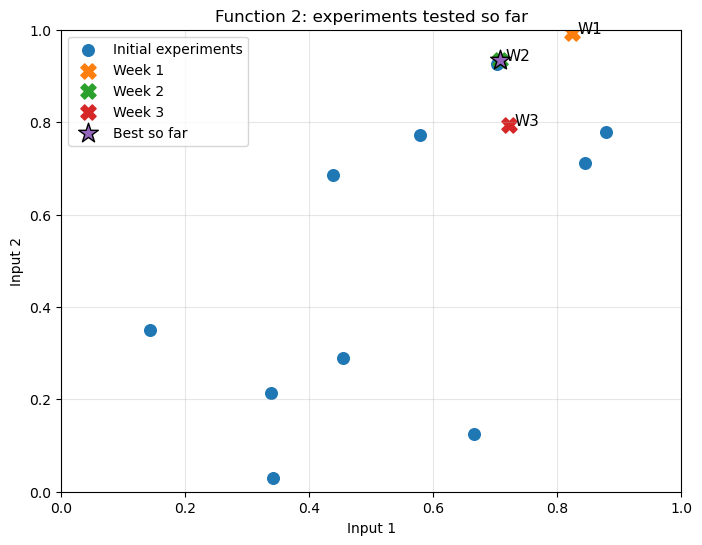

In [6]:
plt.figure(figsize=(8, 6))

# Initial points
plt.scatter(
    X_initial[:, 0],
    X_initial[:, 1],
    s=70,
    label="Initial experiments"
)

# Weekly points
plt.scatter(week1_x[:, 0], week1_x[:, 1], s=120, marker="X", label="Week 1")
plt.scatter(week2_x[:, 0], week2_x[:, 1], s=120, marker="X", label="Week 2")
plt.scatter(week3_x[:, 0], week3_x[:, 1], s=120, marker="X", label="Week 3")

# Best point
plt.scatter(
    best_x[0],
    best_x[1],
    s=220,
    marker="*",
    edgecolor="black",
    label="Best so far"
)

# Add labels for weekly points
plt.text(week1_x[0, 0] + 0.01, week1_x[0, 1], "W1", fontsize=11)
plt.text(week2_x[0, 0] + 0.01, week2_x[0, 1], "W2", fontsize=11)
plt.text(week3_x[0, 0] + 0.01, week3_x[0, 1], "W3", fontsize=11)

plt.title("Function 2: experiments tested so far")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

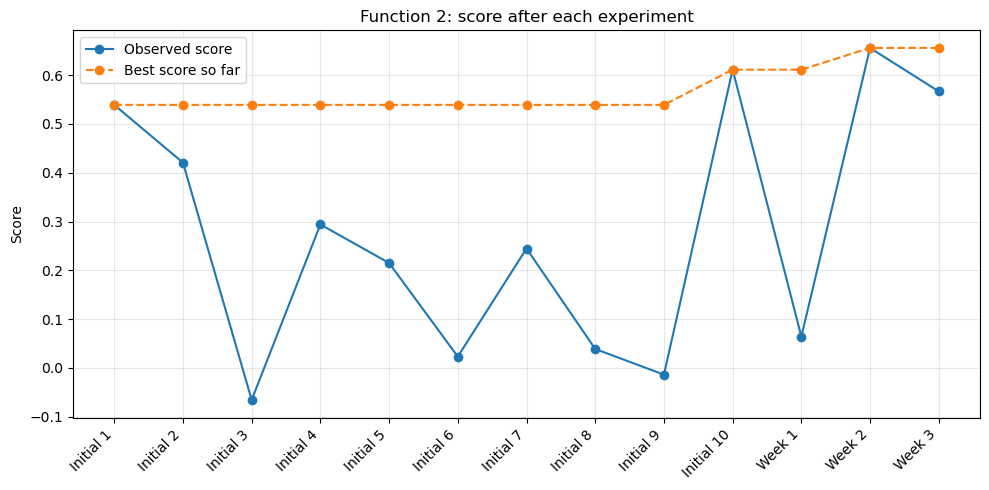

In [7]:
run_names = [f"Initial {i+1}" for i in range(len(Y_initial))] + ["Week 1", "Week 2", "Week 3"]
best_so_far = np.maximum.accumulate(Y)

plt.figure(figsize=(10, 5))

plt.plot(run_names, Y, marker="o", label="Observed score")
plt.plot(run_names, best_so_far, marker="o", linestyle="--", label="Best score so far")

plt.xticks(rotation=45, ha="right")
plt.title("Function 2: score after each experiment")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Use data available after Week 2, before Week 3 was known
X_train = np.vstack([X_initial, week1_x, week2_x])
Y_train = np.concatenate([Y_initial, week1_y, week2_y])

best_idx_train = np.argmax(Y_train)
best_x_train = X_train[best_idx_train]
best_y_train = Y_train[best_idx_train]

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(length_scale=np.ones(X_train.shape[1]) * 0.2, length_scale_bounds=(1e-2, 1.0), nu=2.5)
    + WhiteKernel(noise_level=1e-8, noise_level_bounds=(1e-10, 1e-3))
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp.fit(X_train, Y_train)

print("Fitted kernel:", gp.kernel_)
print("Best available before Week 3:", best_y_train)
print("Best point before Week 3:", best_x_train)

Fitted kernel: 0.956**2 * Matern(length_scale=[0.0335, 1], nu=2.5) + WhiteKernel(noise_level=0.001)
Best available before Week 3: 0.6557263198296742
Best point before Week 3: [0.706793 0.934497]


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.001. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
grid_size = 150

x1 = np.linspace(0, 1, grid_size)
x2 = np.linspace(0, 1, grid_size)

xx, yy = np.meshgrid(x1, x2)

grid = np.column_stack([
    xx.ravel(),
    yy.ravel()
])

mean, std = gp.predict(grid, return_std=True)

mean_grid = mean.reshape(xx.shape)
std_grid = std.reshape(xx.shape)

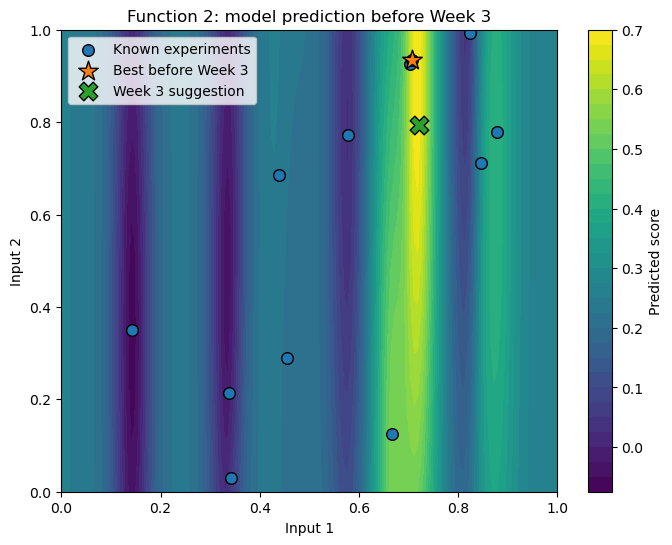

In [10]:
plt.figure(figsize=(8, 6))

contour = plt.contourf(xx, yy, mean_grid, levels=30)
plt.colorbar(contour, label="Predicted score")

plt.scatter(X_train[:, 0], X_train[:, 1], s=70, edgecolor="black", label="Known experiments")
plt.scatter(best_x_train[0], best_x_train[1], s=220, marker="*", edgecolor="black", label="Best before Week 3")

plt.scatter(week3_x[0, 0], week3_x[0, 1], s=180, marker="X", edgecolor="black", label="Week 3 suggestion")

plt.title("Function 2: model prediction before Week 3")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

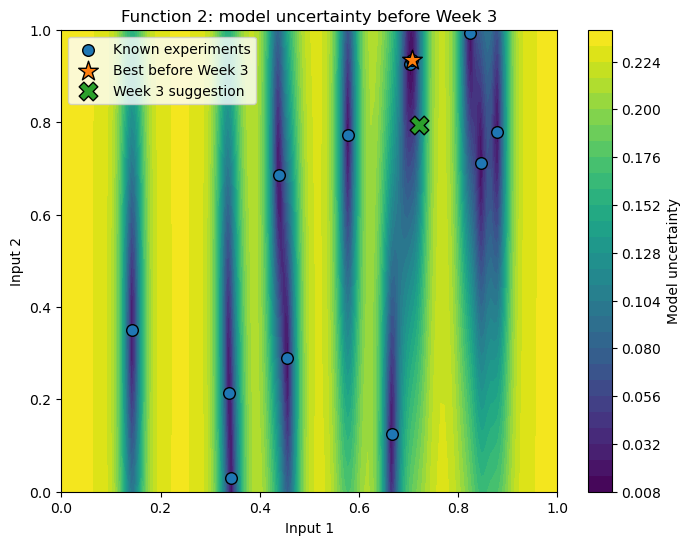

In [11]:
plt.figure(figsize=(8, 6))

contour = plt.contourf(xx, yy, std_grid, levels=30)
plt.colorbar(contour, label="Model uncertainty")

plt.scatter(X_train[:, 0], X_train[:, 1], s=70, edgecolor="black", label="Known experiments")
plt.scatter(best_x_train[0], best_x_train[1], s=220, marker="*", edgecolor="black", label="Best before Week 3")
plt.scatter(week3_x[0, 0], week3_x[0, 1], s=180, marker="X", edgecolor="black", label="Week 3 suggestion")

plt.title("Function 2: model uncertainty before Week 3")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [12]:
# -----------------------------
# Expected Improvement
# -----------------------------
y_best = np.max(Y_train)
std_safe = std + 1e-12

improvement = mean - y_best
z = improvement / std_safe
ei = improvement * norm.cdf(z) + std_safe * norm.pdf(z)

# -----------------------------
# Upper Confidence Bound
# -----------------------------
kappa = 1.5
ucb = mean + kappa * std

# -----------------------------
# Normalised hybrid score
# -----------------------------
ei_norm = (ei - np.min(ei)) / (np.max(ei) - np.min(ei) + 1e-12)
ucb_norm = (ucb - np.min(ucb)) / (np.max(ucb) - np.min(ucb) + 1e-12)

hybrid_score = 0.65 * ei_norm + 0.35 * ucb_norm
hybrid_grid = hybrid_score.reshape(xx.shape)

# Best point on the grid according to acquisition
grid_best_idx = np.argmax(hybrid_score)
grid_suggested_point = grid[grid_best_idx]

print("Grid suggested point:", grid_suggested_point)
print("Your Week 3 point:", week3_x[0])

Grid suggested point: [0.71812081 0.75838926]
Your Week 3 point: [0.721184 0.79359 ]


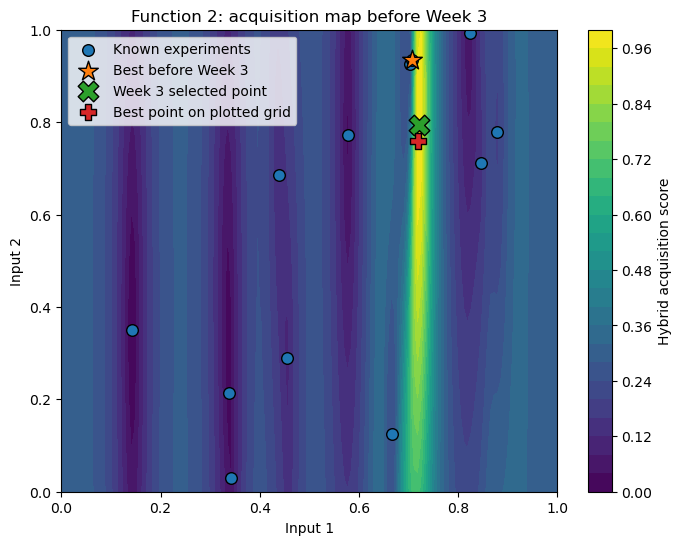

In [13]:
plt.figure(figsize=(8, 6))

contour = plt.contourf(xx, yy, hybrid_grid, levels=30)
plt.colorbar(contour, label="Hybrid acquisition score")

plt.scatter(X_train[:, 0], X_train[:, 1], s=70, edgecolor="black", label="Known experiments")
plt.scatter(best_x_train[0], best_x_train[1], s=220, marker="*", edgecolor="black", label="Best before Week 3")

plt.scatter(
    week3_x[0, 0],
    week3_x[0, 1],
    s=220,
    marker="X",
    edgecolor="black",
    label="Week 3 selected point"
)

plt.scatter(
    grid_suggested_point[0],
    grid_suggested_point[1],
    s=120,
    marker="P",
    edgecolor="black",
    label="Best point on plotted grid"
)

plt.title("Function 2: acquisition map before Week 3")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [17]:
print("Week 3 selected point:", week3_x[0])
print("Predicted before Week 3:", gp.predict(week3_x)[0])
print("Actual Week 3 result:", week3_y[0])
print("Best before Week 3:", best_y_train)

if week3_y[0] > best_y_train:
    print("Week 3 improved the best result.")
else:
    print("Week 3 did not improve the best result, but it added information about the region.")

Week 3 selected point: [0.721184 0.79359 ]
Predicted before Week 3: 0.6851899950654076
Actual Week 3 result: 0.5666392751992081
Best before Week 3: 0.6557263198296742
Week 3 did not improve the best result, but it added information about the region.


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.001. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


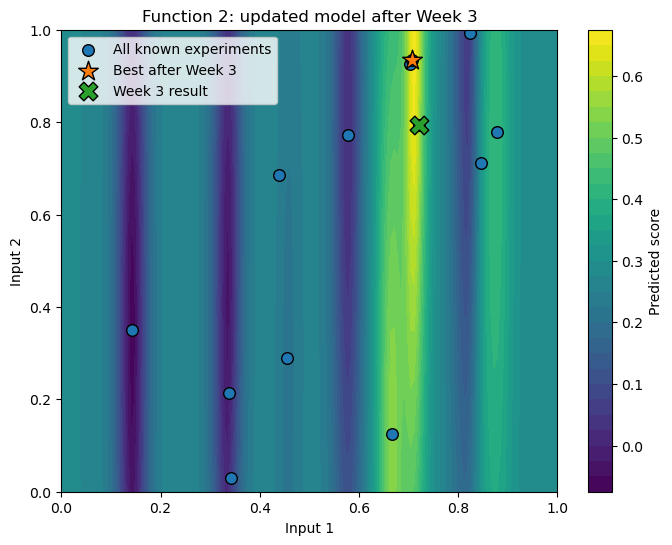

In [18]:
gp_after = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=10,
    random_state=42
)

gp_after.fit(X, Y)

mean_after, std_after = gp_after.predict(grid, return_std=True)
mean_after_grid = mean_after.reshape(xx.shape)

plt.figure(figsize=(8, 6))

contour = plt.contourf(xx, yy, mean_after_grid, levels=30)
plt.colorbar(contour, label="Predicted score")

plt.scatter(X[:, 0], X[:, 1], s=70, edgecolor="black", label="All known experiments")
plt.scatter(best_x[0], best_x[1], s=220, marker="*", edgecolor="black", label="Best after Week 3")
plt.scatter(week3_x[0, 0], week3_x[0, 1], s=180, marker="X", edgecolor="black", label="Week 3 result")

plt.title("Function 2: updated model after Week 3")
plt.xlabel("Input 1")
plt.ylabel("Input 2")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.show()

In [19]:
#week 4 
# start with building the complete dataset 

X = np.load("function2/initial_inputs.npy")
Y = np.load("function2/initial_outputs.npy")

week1_x = np.array([[0.823017, 0.992216]])
week1_y = np.array([0.06417048162449789])

week2_x = np.array([[0.706793, 0.934497]])
week2_y = np.array([0.6557263198296742])

week3_x = np.array([[0.721184, 0.793590]])
week3_y = np.array([0.5666392751992081])

X = np.vstack([
    X,
    week1_x,
    week2_x,
    week3_x
])

Y = np.append(Y, [
    week1_y[0],
    week2_y[0],
    week3_y[0]
])

best_index = np.argmax(Y)
best_x = X[best_index]
best_y = Y[best_index]

print("Best x:", best_x)
print("Best y:", best_y)

Best x: [0.706793 0.934497]
Best y: 0.6557263198296742


In [20]:
# lets look where we are so far

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.ones(2) * 0.2,
        length_scale_bounds=(1e-2, 2.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-8,
        noise_level_bounds=(1e-10, 1e-3)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=20,
    random_state=42
)

gp.fit(X, Y)

print("Fitted kernel:", gp.kernel_)

Fitted kernel: 0.904**2 * Matern(length_scale=[0.0253, 1.68], nu=2.5) + WhiteKernel(noise_level=0.001)


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.001. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [7]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel as C,
    Matern,
    WhiteKernel
)

kernel = (
    C(1.0, (1e-3, 1e3))
    * Matern(
        length_scale=np.ones(2) * 0.2,
        length_scale_bounds=(1e-2, 1.0),
        nu=2.5
    )
    + WhiteKernel(
        noise_level=1e-8,
        noise_level_bounds=(1e-10, 1e-3)
    )
)

gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=15,
    random_state=42
)

gp.fit(X, Y)

print("Fitted kernel:", gp.kernel_)

Fitted kernel: 0.887**2 * Matern(length_scale=[0.0258, 1], nu=2.5) + WhiteKernel(noise_level=0.001)


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.001. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [21]:
# Create mostly local candidates around the current best, this builds a trust region 


trust_radius = np.array([0.15, 0.15])

lower_bounds = np.maximum(
    0,
    best_x - trust_radius
)

upper_bounds = np.minimum(
    1,
    best_x + trust_radius
)

bounds = list(zip(lower_bounds, upper_bounds))

print("Trust-region lower bounds:", lower_bounds)
print("Trust-region upper bounds:", upper_bounds)

Trust-region lower bounds: [0.556793 0.784497]
Trust-region upper bounds: [0.856793 1.      ]


In [22]:
# Remove candidates too close to points you have already tested:
kappa = 0.75

def negative_ucb(point):
    point = np.asarray(point).reshape(1, -1)

    mean, std = gp.predict(
        point,
        return_std=True
    )

    ucb = mean[0] + kappa * std[0]

    # scipy minimises, so return the negative
    return -ucb

In [23]:
from scipy.optimize import minimize

rng = np.random.default_rng(42)

starting_points = [
    best_x,
    week2_x[0],
    week3_x[0]
]

random_starts = rng.uniform(
    lower_bounds,
    upper_bounds,
    size=(25, 2)
)

starting_points.extend(random_starts)

results = []

for start in starting_points:
    result = minimize(
        negative_ucb,
        x0=start,
        method="L-BFGS-B",
        bounds=bounds
    )

    if result.success:
        results.append(result)

best_result = min(
    results,
    key=lambda result: result.fun
)

query = best_result.x

In [11]:

# Identify candidate “boundary-like” observations
threshold = np.percentile(Y, 75)
promising = (Y >= threshold).astype(int)

print("75th percentile threshold:", threshold)
print("Promising labels:", promising)
print("Number of promising points:", promising.sum())

75th percentile threshold: 0.5389961189269181
Promising labels: [1 0 0 0 0 0 0 0 0 1 0 1 1]
Number of promising points: 4


In [24]:
query_mean, query_std = gp.predict(
    query.reshape(1, -1),
    return_std=True
)

query_ucb = (
    query_mean[0]
    + kappa * query_std[0]
)

nearest_distance = np.min(
    np.linalg.norm(X - query, axis=1)
)

print("Method: Trust-region GP-UCB with L-BFGS-B")
print("Suggested Week 4 query:", query)

print(
    "Portal format:",
    "-".join(f"{value:.6f}" for value in query)
)

print("Predicted mean:", query_mean[0])
print("Predicted std:", query_std[0])
print("UCB:", query_ucb)
print(
    "Distance to nearest observation:",
    nearest_distance
)

Method: Trust-region GP-UCB with L-BFGS-B
Suggested Week 4 query: [0.71117711 1.        ]
Portal format: 0.711177-1.000000
Predicted mean: 0.6639266679383273
Predicted std: 0.024219201408454318
UCB: 0.6820910689946681
Distance to nearest observation: 0.06564955003113851


In [14]:
svc = svm_model.named_steps["svc"]
support_indices = svc.support_

support_points = X[support_indices]
support_outputs = Y[support_indices]

print("Support-vector indices:", support_indices)
print("Support-vector inputs:")
print(support_points)
print("Their outputs:")
print(support_outputs)

Support-vector indices: [ 1  3  4  5  6  7 10  0  9 11 12]
Support-vector inputs:
[[0.87779099 0.7786275 ]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.823017   0.992216  ]
 [0.66579958 0.12396913]
 [0.70263656 0.9265642 ]
 [0.706793   0.934497  ]
 [0.721184   0.79359   ]]
Their outputs:
[0.42058624 0.29399291 0.21496451 0.02310555 0.24461934 0.03874902
 0.06417048 0.53899612 0.61120522 0.65572632 0.56663928]


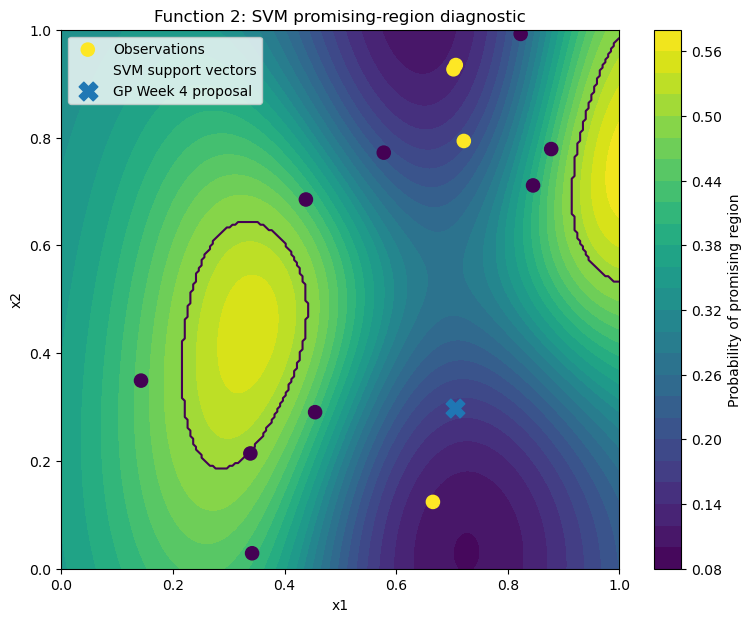

In [15]:
grid_size = 200

x1_grid = np.linspace(0, 1, grid_size)
x2_grid = np.linspace(0, 1, grid_size)

X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

grid_points = np.column_stack([
    X1_grid.ravel(),
    X2_grid.ravel()
])

promising_probability = svm_model.predict_proba(grid_points)[:, 1]
promising_probability = promising_probability.reshape(X1_grid.shape)

plt.figure(figsize=(9, 7))

contour = plt.contourf(
    X1_grid,
    X2_grid,
    promising_probability,
    levels=30
)

plt.colorbar(contour, label="Probability of promising region")

plt.contour(
    X1_grid,
    X2_grid,
    promising_probability,
    levels=[0.5]
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=promising,
    s=90,
    label="Observations"
)

plt.scatter(
    support_points[:, 0],
    support_points[:, 1],
    facecolors="none",
    s=220,
    linewidths=2,
    label="SVM support vectors"
)

plt.scatter(
    query[0],
    query[1],
    marker="X",
    s=180,
    label="GP Week 4 proposal"
)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Function 2: SVM promising-region diagnostic")
plt.legend()
plt.show()

In [16]:
query_probability = svm_model.predict_proba(
    query.reshape(1, -1)
)[0, 1]

print(
    "SVM probability that GP query is promising:",
    query_probability
)

SVM probability that GP query is promising: 0.17024683913802455


In [17]:
print("GP query:", query)
print("GP predicted mean:", mean[query_index])
print("GP predicted std:", std[query_index])
print("Expected Improvement:", ei[query_index])
print("SVM promising probability:", query_probability)
print("Distance to nearest observation:",
      np.min(np.linalg.norm(X - query, axis=1)))

GP query: [0.70611019 0.29814744]
GP predicted mean: 0.5417408281737026
GP predicted std: 0.13732565512713557
Expected Improvement: 0.013719695175659189
SVM promising probability: 0.17024683913802455
Distance to nearest observation: 0.1787820749020398
